In [1]:
import numpy as np
import pandas as pd
import re
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
df=pd.read_csv('/content/gurgaon_properties_cleaned_v1.csv')

In [3]:
df.duplicated().sum()

np.int64(122)

In [4]:
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,house,bestech park view aindependentda,sector 81,4.35,7937.0,5481.0,Plot area 5480(509.11 sq.m.),4,4,3,"store room,servant room",2.0,North,1 to 5 Year Old,"['Metro Station Kankrola sec 87', 'Sapphire 83 Mall', 'Dwarka Expressway', ""St. Xavier's High School"", 'Miracles Apollo Cradle /Spectra Hospital', 'Indira Gandhi International Airport', 'IMT Manesar', 'Heritage Village Resort & Spa', 'SkyJumper Trampoline Park', 'National Tennis Academy']",NaN,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'Separate entry for servant room', 'Bank Attached Property', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']"


*`focus is on -> areaWithType, additionalRoom, agePossession, furnishDetails, features `*

# ***`1. areawithtype`***

In [5]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
710,1.25,1930.0,Super Built up area 1930(179.3 sq.m.)Built Up area: 1929 sq.ft. (179.21 sq.m.)Carpet area: 1928 sq.ft. (179.12 sq.m.)
1657,1.06,1671.0,Super Built up area 1671(155.24 sq.m.)
2878,6.50,6240.0,Built Up area: 4800 (445.93 sq.m.)
3158,2.05,2600.0,Built Up area: 2600 (241.55 sq.m.)Carpet area: 2400 sq.ft. (222.97 sq.m.)
1393,6.21,2700.0,Plot area 300(250.84 sq.m.)


In [6]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [7]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [8]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [9]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [10]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2695,0.45,house,50.0,Built Up area: 50 (4.65 sq.m.),NaN,50.0,NaN
973,1.51,flat,1914.0,Super Built up area 1920(178.37 sq.m.),1920.0,NaN,NaN
2017,0.90,flat,1350.0,Super Built up area 1350(125.42 sq.m.),1350.0,NaN,NaN
1972,1.70,flat,809.0,Super Built up area 1395(129.6 sq.m.)Carpet area: 809 sq.ft. (75.16 sq.m.),1395.0,NaN,809.0
163,8.25,house,2160.0,Plot area 350(292.64 sq.m.)Built Up area: 300 sq.yards (250.84 sq.m.)Carpet area: 240 sq.yards (200.67 sq.m.),NaN,300.0,240.0


In [11]:
df.duplicated().sum()

np.int64(122)

In [12]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [13]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,4.35,house,5481.0,Plot area 5480(509.11 sq.m.),NaN,NaN,NaN
2,NaN,house,NaN,Plot area 350(292.64 sq.m.),NaN,NaN,NaN
5,1.27,house,1570.0,Plot area 1570(145.86 sq.m.),NaN,NaN,NaN
8,7.25,house,2471.0,Plot area 303(253.35 sq.m.),NaN,NaN,NaN
9,6.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN


In [14]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,18
price_per_sqft,18
area,18
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [15]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [16]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,4.35,house,5481.0,Plot area 5480(509.11 sq.m.),NaN,NaN,NaN
2,NaN,house,NaN,Plot area 350(292.64 sq.m.),NaN,NaN,NaN
5,1.27,house,1570.0,Plot area 1570(145.86 sq.m.),NaN,NaN,NaN
8,7.25,house,2471.0,Plot area 303(253.35 sq.m.),NaN,NaN,NaN
9,6.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN


In [17]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [18]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [19]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

# Update the original dataframe
#gurgaon_properties.update(filtered_rows)

In [20]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,4.35,house,5481.0,Plot area 5480(509.11 sq.m.),NaN,5480.00,NaN
2,NaN,house,NaN,Plot area 350(292.64 sq.m.),NaN,350.00,NaN
5,1.27,house,1570.0,Plot area 1570(145.86 sq.m.),NaN,1570.00,NaN
8,7.25,house,2471.0,Plot area 303(253.35 sq.m.),NaN,303.00,NaN
9,6.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,300.00,NaN
10,5.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
12,2.00,house,1337.0,Plot area 1337.4(124.25 sq.m.),NaN,1337.40,NaN
16,3.15,house,1548.0,Plot area 172(143.81 sq.m.),NaN,172.00,NaN
27,4.00,house,1836.0,Plot area 204(170.57 sq.m.),NaN,204.00,NaN
40,16.00,house,4571.0,Plot area 500(418.06 sq.m.),NaN,500.00,NaN


In [21]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [22]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [23]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,4.35,house,5481.0,Plot area 5480(509.11 sq.m.),NaN,5480.00,NaN
2,NaN,house,NaN,Plot area 350(292.64 sq.m.),NaN,350.00,NaN
5,1.27,house,1570.0,Plot area 1570(145.86 sq.m.),NaN,1570.00,NaN
8,7.25,house,2471.0,Plot area 303(253.35 sq.m.),NaN,303.00,NaN
9,6.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,2700.00,NaN
10,5.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
12,2.00,house,1337.0,Plot area 1337.4(124.25 sq.m.),NaN,1337.40,NaN
16,3.15,house,1548.0,Plot area 172(143.81 sq.m.),NaN,1548.00,NaN
27,4.00,house,1836.0,Plot area 204(170.57 sq.m.),NaN,1836.00,NaN
40,16.00,house,4571.0,Plot area 500(418.06 sq.m.),NaN,4500.00,NaN


In [24]:
# update the original dataframe
df.update(all_nan_df)

In [25]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,18
price_per_sqft,18
area,18
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [26]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
2689,flat,signature the roselia,sector 95,0.41,6194.0,662.0,Built Up area: 670 (62.25 sq.m.)Carpet area: 569.25 sq.ft. (52.89 sq.m.),2,2,2,study room,12.0,North,0 to 1 Year Old,"['Newtown Square Mall', 'Pataudi Road', 'Dwarka Expressway', 'NH-48', 'Yaduvanshi Shiksha Niketan', 'Gurugram University Sector 87', 'Aarvy Healthcare', 'Indira Gandhi International Airport', 'IMT Manesar', 'Holiday Inn Sector 90', 'National Tennis Academy', 'CNG Petrol Pump']","['2 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Stove', '4 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Visitor Parking', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Shopping Centre', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']",NaN,670.0,569.25
161,flat,raheja vanya,sector 99a,0.59,3975.0,1484.0,Super Built up area 1252.13(116.33 sq.m.),2,2,3,others,1.0,East,Dec 2023,"['The Esplanade Mall', 'Dwarka Expy', 'Suncity School', 'Govt. PG College, Basai Rd', 'The Signature Advanced Super Speciality', 'Sheetla Hospital', 'Indira Gandhi International Airport', 'Basai Dhankot Railway Station', 'Satya The Hive, Dwarka Expy', 'Golden Creepers Farm Retreat', 'Holiday Inn Gurugram Sector 90', 'Nehru Stadium', 'Tau DeviLal Sports Complex']","['3 Fan', '1 Exhaust Fan', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",1252.13,NaN,NaN
1716,flat,sare crescent parc royal greens phase 1,sector 92,0.50,5000.0,1000.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 999 sq.ft. (92.81 sq.m.),2,2,3,not available,2.0,North-East,undefined,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. Sarkar Clinic', 'Vijay Petrol Pump', 'HP Petrol Pump', 'Indian Oil', 'Essar Petrol Pump', 'Garhi harsaru junction railway station']","['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN,NaN,1000.0,999.00
2166,flat,m3m urbana,sector 67,0.95,10895.0,872.0,Built Up area: 826 (76.74 sq.m.),1,1,1,not available,17.0,South-West,1 to 5 Year Old,"['Sri Radhe Krishna Temple', 'Kamal Hospital and Maternity Centre', 'Gobind Hospital', 'Sona Devi Memorial Hospital and Trauma Centre', 'Sanjeevani Hospital Gurgaon', 'Sai Dharamraj Hospital', 'Sai Heart and Trauma Center', 'Ekta Hospital', 'Vatsalya Clinic', 'Wembley estate club', 'SPAZE BUSINESS PARK', 'Kore Tech Park', 'Icici bank', 'State bank of india', 'Union bank of india', 'Hdfc bank', 'Central bank of india', 'Indusind bank', 'Hdfc bank', 'Madison and Pike', 'India', 'Starbucks', 'Nook']",NaN,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",NaN,826.0,NaN
1197,flat,godrej oasis,sector 88a,1.50,8108.0,1850.0,Carpet area: 1850 (171.87 sq.m.),3,3,2,no

# ***`2.additionalRoom`***

In [27]:
df['additionalRoom'].value_counts()

,count
additionalRoom,
not available,1587
servant room,705
study room,250
others,225
pooja room,165
"study room,servant room",99
store room,99
"pooja room,servant room",82
"pooja room,study room,servant room,store room",72


In [28]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [29]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
1280,others,0,0,0,0,1
753,"pooja room,study room",1,0,0,1,0
728,not available,0,0,0,0,0
1623,"pooja room,servant room",0,1,0,1,0
588,servant room,0,1,0,0,0


In [30]:
df.sample()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
502,flat,tulip violet,sector 69,1.72,8730.0,1970.0,Super Built up area 1970(183.02 sq.m.),4,4,1,not available,12.0,North-East,1 to 5 Year Old,"['Airia Mall Sector 68', 'Southern Peripheral Road', 'Golf Course Extension Rd', 'Imperio School', 'DPG Institute of Technology', 'Ektaa Hospitals', 'Indira Gandhi International Airport', 'Vipul Trade Business Centre', 'Radisson Hotel Gurugram', 'SkyJumper Trampoline Park']","['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Airy Rooms', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']",1970.0,NaN,NaN,0,0,0,0,0


# ***`3.agePossession`***

In [31]:
df['agePossession'].value_counts()

,count
agePossession,
1 to 5 Year Old,1676
5 to 10 Year Old,575
0 to 1 Year Old,530
undefined,332
10+ Year Old,310
Under Construction,90
Within 6 months,70
Within 3 months,26
Dec 2023,22


In [32]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [33]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [34]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1676
New Property,626
Moderately Old,575
Undefined,333
Old Property,310
Under Construction,283


In [35]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,house,bestech park view aindependentda,sector 81,4.35,7937.0,5481.0,Plot area 5480(509.11 sq.m.),4,4,3,"store room,servant room",2.0,North,Relatively New,"['Metro Station Kankrola sec 87', 'Sapphire 83 Mall', 'Dwarka Expressway', ""St. Xavier's High School"", 'Miracles Apollo Cradle /Spectra Hospital', 'Indira Gandhi International Airport', 'IMT Manesar', 'Heritage Village Resort & Spa', 'SkyJumper Trampoline Park', 'National Tennis Academy']",NaN,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'Separate entry for servant room', 'Bank Attached Property', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']",NaN,5480.0,NaN,0,1,1,0,0
1,flat,signature global solera,sector 107,0.28,5674.0,493.0,Carpet area: 489 (45.43 sq.m.),2,2,2,not available,6.0,West,Relatively New,"['Gurgaon Dreamz Mall', 'Dwarka Expressway', ""Colonel's Central Academy"", 'The NorthCap University', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Trident Hotel Gurgaon', 'Fun N Food Village', 'DLF Golf and Country Club', 'F9 Go Karting Gurgaon', 'SkyJumper Trampoline Park Gurgaon']",NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Park', 'Natural Light', 'Airy Rooms', 'Fitness Centre / GYM', 'Waste Disposal']",NaN,NaN,489.0,0,0,0,0,0
2,house,emaar mgf marbella,sector 66,NaN,NaN,NaN,Plot area 350(292.64 sq.m.),5,5,3,not available,2.0,NaN,Relatively New,"['Sector 55-56 Rapid Metro Station', 'HUB 66', 'NH 48', 'Hasanpur', 'Gurugram University', 'Delhi Public School', 'Park Hospital', 'Indira Gandhi International Airport', 'Sealdah', 'Vatika Business Centre', 'The Oberoi', 'De Adventure Park', 'DLF Golf and Country Club', 'Tau DeviLal Sports Complex']","['5 Fan', '1 Exhaust Fan', '6 Geyser', '1 Microwave', '7 Light', '5 AC', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Modular Kitchen', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Private Garden / Terrace', 'Maintenance Staff', 'Water Storage', 'Club house / Community Center']",NaN,350.0,NaN,0,0,0,0,0
3,flat,hcbs sports ville,sohna road,0.29,5587.0,519.0,Carpet area: 519 (48.22 sq.m.),2,2,1,not available,4.0,NaN,Relatively New,"['The roadside cafe', 'GD Goenka Mess', 'ROyal Kitchen', 'Mithaas Wala', 'Momomia Gurgoan']",NaN,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",NaN,NaN,519.0,0,0,0,0,0
4,flat,orchid petals,sector 49,2.55,12318.0,2070.0,Super Built up area 2070(192.31 sq.m.)Built Up area: 2060 sq.ft. (191.38 sq.m.)Carpet area: 1760 sq.ft. (163.51 sq.m.),3,4,3,study room,8.0,East,Relatively New,"['Sapphire Mall', 'Omaxe City Centre', 'BigBazaar', 'Sohna Rd', 'Kinder Care Playschool', 'Kangaroo Kids Preschool', 'shiv Mandir', 'Polaris Hospital', 'Medanta Hospital', 'Artemis Hospital', 'HDFC Bank', 'Radisson Hotel', 'SRS Cinemas']","['8 Fan', '1 Exhaust Fan', '3 Geyser', '8 Light', '1 Chimney', '1 Curtains', '1 Modular Kitchen', '4 Wardrobe', 'No AC', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",2070.0,2060.0,1760.0,1,0,0,0,0


# ***`4.furnishDetails`***

In [36]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
3398,NaN,"['Intercom Facility', 'Lift(s)', 'Park']"
1219,[],NaN
2695,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN
3480,"['1 Water Purifier', '1 Fridge', '1 Sofa', '1 Exhaust Fan', '1 Washing Machine', '1 Microwave', '26 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Fan', 'No Geyser', 'No Light', 'No Stove', 'No TV', 'No Wardrobe']",NaN
229,"['3 Wardrobe', '3 Fan', '1 Exhaust Fan', '2 Geyser', '1 Microwave', '5 Light', '2 AC', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Modular Kitchen', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Water purifier', 'Centrally Air Conditioned', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Spacious Interiors', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"


In [37]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1873/2445438592.py:13: SyntaxWarning: invalid escape sequence '\d'
  pattern = re.compile(f"(\d+) {furnishing}")


In [38]:
furnishings_df.shape

(3803, 19)

In [39]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

/tmp/ipykernel_1873/114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [40]:
furnishings_df.sample(5)

,Modular Kitchen,Sofa,Curtains,Washing Machine,Fan,Water Purifier,Fridge,Light,Stove,Exhaust Fan,Wardrobe,Chimney,Dining Table,Geyser,TV,Microwave,Bed,AC
1920,1,0,0,0,7,0,0,22,0,1,5,0,0,5,0,0,0,0
2035,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3498,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2517,0,0,1,0,1,0,0,2,0,1,0,0,0,0,0,0,0,0
611,1,1,1,0,2,0,0,3,0,0,1,1,1,1,0,0,1,1


In [41]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [44]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

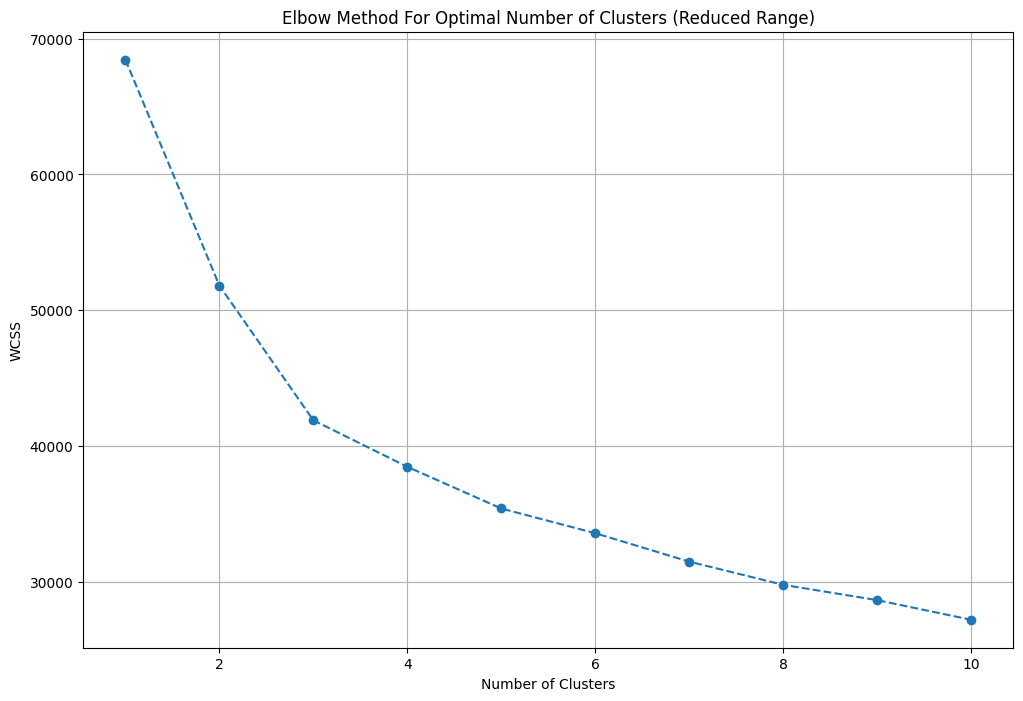

In [45]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [46]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [47]:
df = df.iloc[:,:-18]

In [48]:
df['furnishing_type'] = cluster_assignments

In [63]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
3688,"['2 Wardrobe', '4 Fan', '5 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0
1255,"['6 Fan', '1 Exhaust Fan', '4 Geyser', '18 Light', '4 AC', '1 Chimney', '1 Modular Kitchen', '4 Wardrobe', '1 Microwave', 'No Bed', 'No Curtains', 'No Dining Table', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",1
1560,NaN,0
988,"['1 Water Purifier', '9 Fan', '1 Exhaust Fan', '1 Dining Table', '4 Geyser', '1 Stove', '25 Light', '6 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', '3 Bed', '9 Wardrobe', '1 Sofa', '1 Washing Machine', 'No Microwave', 'No Fridge', 'No TV']",2
975,"['5 Fan', '15 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0


# ***`5.features`***

In [64]:
df[['society','features']].sample(5)

,society,features
3076,umang winter hills,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
658,godrej oasis,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
386,sidhartha ncr one phase,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']"
3002,alpha corp gurgaonone,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Park', 'Visitor Parking']"
695,vatika city homes,"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Park', 'Visitor Parking', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"


In [67]:
df['features'].isnull().sum()

np.int64(635)

In [68]:
import pandas as pd
app_df = pd.read_csv('/content/appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [69]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [70]:
temp_df = df[df['features'].isnull()]

In [71]:
temp_df.shape

(635, 26)

In [72]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [73]:
df.loc[temp_df.index,'features'] = x.values

In [74]:
df['features'].isnull().sum()

np.int64(481)

In [75]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [76]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [77]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
1607,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2968,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0
3640,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0
925,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
3402,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0


In [78]:
features_binary_df.shape

(3803, 130)

In [79]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

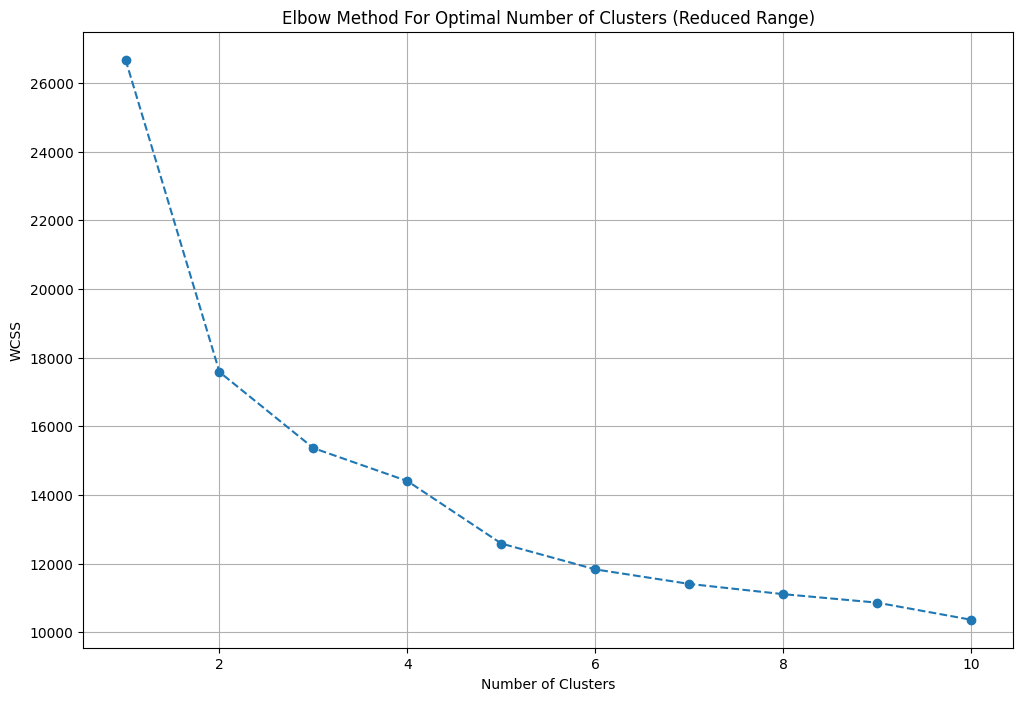

In [80]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [81]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [82]:
df['luxury_score'] = luxury_score

In [83]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,house,bestech park view aindependentda,sector 81,4.35,7937.0,5481.0,Plot area 5480(509.11 sq.m.),4,4,3,"store room,servant room",2.0,North,Relatively New,"['Metro Station Kankrola sec 87', 'Sapphire 83 Mall', 'Dwarka Expressway', ""St. Xavier's High School"", 'Miracles Apollo Cradle /Spectra Hospital', 'Indira Gandhi International Airport', 'IMT Manesar', 'Heritage Village Resort & Spa', 'SkyJumper Trampoline Park', 'National Tennis Academy']",NaN,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'Separate entry for servant room', 'Bank Attached Property', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']",NaN,5480.0,NaN,0,1,1,0,0,0,"[Feng Shui / Vaastu Compliant, Private Garden / Terrace, High Ceiling Height, Maintenance Staff, Separate entry for servant room, Bank Attached Property, Fitness Centre / GYM, Club house / Community Center, Rain Water Harvesting]",51
1,flat,signature global solera,sector 107,0.28,5674.0,493.0,Carpet area: 489 (45.43 sq.m.),2,2,2,not available,6.0,West,Relatively New,"['Gurgaon Dreamz Mall', 'Dwarka Expressway', ""Colonel's Central Academy"", 'The NorthCap University', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Trident Hotel Gurgaon', 'Fun N Food Village', 'DLF Golf and Country Club', 'F9 Go Karting Gurgaon', 'SkyJumper Trampoline Park Gurgaon']",NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Park', 'Natural Light', 'Airy Rooms', 'Fitness Centre / GYM', 'Waste Disposal']",NaN,NaN,489.0,0,0,0,0,0,0,"[Power Back-up, Intercom Facility, Lift(s), Maintenance Staff, Park, Natural Light, Airy Rooms, Fitness Centre / GYM, Waste Disposal]",45
2,house,emaar mgf marbella,sector 66,NaN,NaN,NaN,Plot area 350(292.64 sq.m.),5,5,3,not available,2.0,NaN,Relatively New,"['Sector 55-56 Rapid Metro Station', 'HUB 66', 'NH 48', 'Hasanpur', 'Gurugram University', 'Delhi Public School', 'Park Hospital', 'Indira Gandhi International Airport', 'Sealdah', 'Vatika Business Centre', 'The Oberoi', 'De Adventure Park', 'DLF Golf and Country Club', 'Tau DeviLal Sports Complex']","['5 Fan', '1 Exhaust Fan', '6 Geyser', '1 Microwave', '7 Light', '5 AC', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Modular Kitchen', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Private Garden / Terrace', 'Maintenance Staff', 'Water Storage', 'Club house / Community Center']",NaN,350.0,NaN,0,0,0,0,0,1,"[Private Garden / Terrace, Maintenance Staff, Water Storage, Club house / Community Center]",22
3,flat,hcbs sports ville,sohna road,0.29,5587.0,519.0,Carpet area: 519 (48.22 sq.m.),2,2,1,not available,4.0,NaN,Relatively New,"['The roadside cafe', 'GD Goenka Mess', 'ROyal Kitchen', 'Mithaas Wala', 'Momomia Gurgoan']",NaN,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",NaN,NaN,519.0,0,0,0,0,0,0,"[Security / Fire Alarm, Intercom Facility, Lift(s), Maintenance Staff, Water Storage, Park, Visitor Parking]",44
4,flat,orchid petals,sector 49,2.55,12318.0,2070.0,Super Built up area 2070(192.31 sq.m.)Built Up area: 2060 sq.ft. (191.38 sq.m.)Carpet area: 1760 sq.ft. (163.51 sq.m.),3,4,3,study room,8.0,East,Relatively New,"['Sapphire Mall', 'Omaxe City Centre', 'BigBazaar', 'Sohna Rd', 'Kinder Care Playschool', 'Kangaroo Kids Preschool', 'shiv Mandir', 'Polaris Hospital', 'Medanta Hospital', 'Artemis Hospital', 'HDFC Bank', 'Radisson Hotel', 'SRS Cinemas']","['8 Fan', '1 Exhaust Fan', '3 Geyser', '8 Light', '1 Chimney', '1 Curtains', '1 Modular Kitchen', '4 Wardr

In [84]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [85]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2486,flat,shapoorji pallonji joyville gurugram,sector 102,1.25,9876.0,1266.0,Super Built up area 1215(112.88 sq.m.),2,2,2,0.0,East,Relatively New,1215.00,NaN,NaN,0,0,0,0,0,0,79
2755,flat,emaar digihomes,sector 62,2.10,14254.0,1473.0,Super Built up area 1508.26(140.12 sq.m.),2,2,2,30.0,North,New Property,1508.26,NaN,NaN,0,1,0,0,0,0,52
1365,flat,chd avenue,sector 71,0.79,6594.0,1198.0,Super Built up area 1198(111.3 sq.m.),2,2,2,8.0,South-East,Relatively New,1198.00,NaN,NaN,0,0,0,0,1,0,0
2737,flat,emaar mgf emerald estate,sector 65,1.30,20602.0,631.0,Super Built up area 1020(94.76 sq.m.)Carpet area: 631 sq.ft. (58.62 sq.m.),2,2,2,7.0,West,Relatively New,1020.00,NaN,631.000000,1,0,0,0,0,0,78
1684,flat,mvn athens,sohna road,0.26,5397.0,482.0,Carpet area: 481.73 (44.75 sq.m.),2,2,1,5.0,NaN,Relatively New,NaN,NaN,481.684525,0,0,0,0,0,0,95


In [86]:
df.shape

(3803, 23)

In [87]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)